# <p style="font-size:100%; text-align:left; color:#444444;">Exploratory Data Analysis - Avian Influenza (Bird Flu)</p>

![Wild Birds](img/wild-geese-pixabay_1149609_1920.jpeg "Word Cloud")

---
# <p style="font-size:100%; text-align:left; color:#444444;">Contents:</p>

* [1. Introduction](#1)
    * [1.1 Questions](#1.1)
* [2. EDA](#2)
    * [2.1 Target variable distribution](#2.1)
    * [2.2 Missing values](#2.2)
* [3. Models](#3)
    * [3.1 LightGBM](#3.1)
* [4. Evaluation](#4)
    * [4.1 Normalized Gini Coefficient](#4.1)
* [5. Conclusion](#5)

<a id="1"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">1- Introduction</p>

<img title="Department of Agriculture, Food and the Marine" src="img/department-of-agriculture-food-and-the-marine.png" alt="Department of Agriculture, Food and the Marine" align="right" style='height:150px; padding: 15px'> This analysis will investigate a dataset provided by Ireland's [Department of Agriculture, Food and the Marine](https://data.gov.ie/dataset/h5n1-wild-bird-species-identification) which contains the locations of bird species captured in Ireland from 1980 to 2020 and wild birds that are targeted for the H5N1 strain of avian flu.

Avian influenza or **"Bird Flu"** is a contagious and often fatal viral disease of birds. Wild birds, particularly wild migratory water birds are considered to be the main reservoir of avian influenza viruses. There is a constant risk of avian influenza being introduced into Ireland from wild birds particularly from November onwards each year as this is when migratory birds arrive and congregate on wetlands, mixing with resident species.

## Questions

1. Which wild bird species were most affected by the avian flu in Ireland?
1. What locations have registered the highest number of wild birds with avian flu?
1. The identification of wild birds with avian flu has been increasing or decreasing throughout the years?
1. What month has the highest number of infected birds?
1. How geographic distributed is the capturing of infected wild birds? (Heatmap and Map count)

## Data Viz

1. Heatmap for most affected areas
2. Map with count of infected birds
3. Line chart with count every year
4. Top 10 most affected species
5. Dashboard with maps and graphs
6. Deployment of ML (selecting parent species, species and location)

In [18]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as grid_spec
import seaborn as sns
import json
from pathlib import Path

%matplotlib inline
#matplotlib.style.use("ggplot")
plt.rcParams["font.family"] = "serif"
plt.rcParams['figure.dpi'] = 100

import geopandas as gpd

import time
import warnings
warnings.simplefilter('ignore', FutureWarning)

In [19]:
from platform import python_version
print('Python version:', python_version())

Python version: 3.8.5


In [20]:
%reload_ext watermark
%watermark -a "Leandro Pessini" --iversions

Author: Leandro Pessini

seaborn   : 0.11.1
json      : 2.0.9
matplotlib: 3.3.2
pandas    : 1.1.3
numpy     : 1.19.2
geopandas : 0.9.0



In [21]:
bird_flu = pd.read_csv("./data/bird-flu.csv", encoding='latin-1')
bird_flu.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16304 entries, 0 to 16303
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Scientific_Name       16304 non-null  object 
 1   Common_Name           16304 non-null  object 
 2   Date                  16304 non-null  object 
 3   Year                  16304 non-null  int64  
 4   Month                 16304 non-null  int64  
 5   Day                   16304 non-null  int64  
 6   Time                  16304 non-null  int64  
 7   Country               16304 non-null  object 
 8   Country_State_County  16304 non-null  object 
 9   State                 16304 non-null  object 
 10  County                16175 non-null  object 
 11  Locality              16304 non-null  object 
 12  Latitude              16304 non-null  float64
 13  Longitude             16304 non-null  float64
 14  Parent_Species        16304 non-null  object 
 15  target_H5_HPAI     

**The dataset does not have missing data.**

In [22]:
bird_flu.head()

,Scientific_Name,Common_Name,Date,Year,Month,Day,Time,Country,Country_State_County,State,County,Locality,Latitude,Longitude,Parent_Species,target_H5_HPAI
0,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
1,Acrocephalus scirpaceus,Eurasian Reed Warbler,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Acrocephalus scirpaceus,0
2,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
3,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0
4,Limosa haemastica,Hudsonian Godwit,15/09/2015,2015,9,15,1100,Ireland,IE-C-GY,Connaught,Galway,Inishmore (Inis Mór),53.1291,-9.7507,Limosa haemastica,0


<a id="2"></a>
# <p style="font-size:100%; text-align:left; color:#444444;">2- Exploratory Data Analysis</p>

## Colour Palette

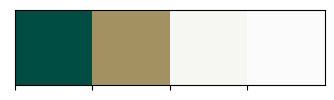

In [23]:
sns.palplot(['#004D44','#A39161','#F6F6F2','#FBFBFB'])

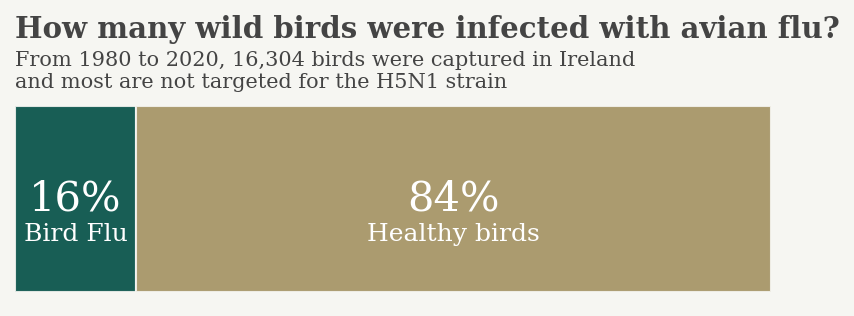

In [24]:
x=bird_flu.groupby(['target_H5_HPAI'])['target_H5_HPAI'].count()
y=len(bird_flu)
r=((x/y)).round(2)
ratio = pd.DataFrame(r).T

fig, ax = plt.subplots(1,1,figsize=(6.5, 1.8),dpi=150)
background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color)
ax.set_facecolor(background_color) 

ax.barh(ratio.index, ratio[1.0], color='#004D44', alpha=0.9, ec=background_color, label='Infected Birds')
ax.barh(ratio.index, ratio[0.0], left=ratio[1.0], color='#A39161', alpha=0.9,ec=background_color, label='Healthy Birds')

ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.legend().set_visible(False)
for s in ['top', 'left', 'right', 'bottom']:
    ax.spines[s].set_visible(False)

for i in ratio.index:
    ax.annotate(f"{int(ratio[1.0][i]*100)}%", xy=(ratio[1.0][i]/2, i),va = 'center', ha='center',fontsize=20, fontweight='light', fontfamily='serif',color='white')
    ax.annotate("Bird Flu", xy=(ratio[1.0][i]/2, -0.15),va = 'center', ha='center',fontsize=12, fontweight='light', fontfamily='serif',color='white')

for i in ratio.index:
    ax.annotate(f"{int(ratio[0.0][i]*100)}%", xy=(ratio[1.0][i]+ratio[0.0][i]/2, i),va = 'center', ha='center',fontsize=20, fontweight='light', fontfamily='serif',color='white')
    ax.annotate("Healthy birds", xy=(ratio[1.0][i]+ratio[0.0][i]/2, -0.15),va = 'center', ha='center',fontsize=12, fontweight='light', fontfamily='serif',color='white')

subtitle = 'From 1980 to 2020, {:,} birds were captured in Ireland \nand most are not targeted for the H5N1 strain'.format(y)
fig.text(0.125,1.1,'How many wild birds were infected with avian flu?', fontfamily='serif',fontsize=14, fontweight='bold', color='#444444')
fig.text(0.125,0.915,subtitle,fontfamily='serif',fontsize=10, color='#444444')  

plt.show()

In [25]:
grouped_scientific_name = pd.DataFrame({'count' : bird_flu.groupby(['Scientific_Name'])['Scientific_Name'].size()}).reset_index()
grouped_common_name = pd.DataFrame({'count' : bird_flu.groupby(['Common_Name'])['Common_Name'].size()}).reset_index()
grouped_parent_species = pd.DataFrame({'count' : bird_flu.groupby(['Parent_Species'])['Parent_Species'].size()}).reset_index()

In [26]:
print("There are {} wild bird species present and {} parent species.".format(len(grouped_common_name), len(grouped_parent_species)))

There are 410 wild bird species present and 338 parent species.


In [27]:
infected_birds = bird_flu[bird_flu['target_H5_HPAI'] == 1]
top_infected_counties = infected_birds.groupby('County').size().sort_values(ascending=False)[:10]

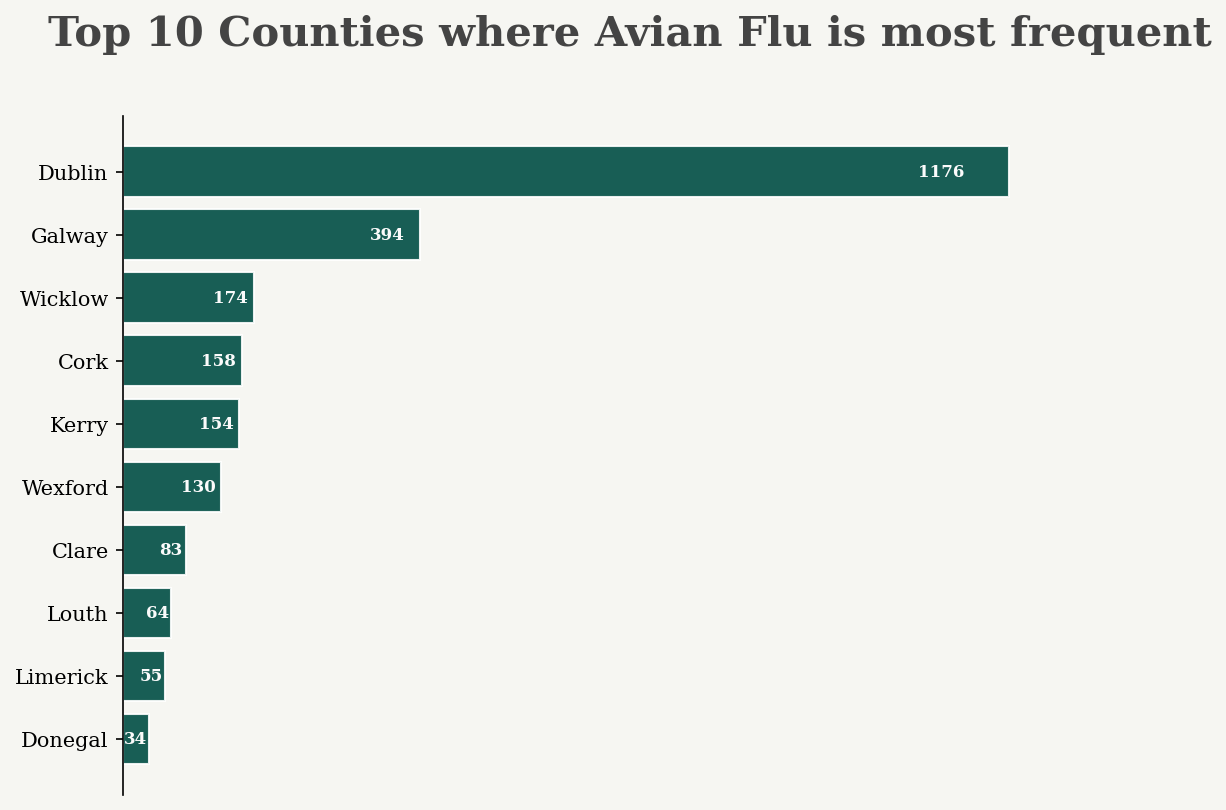

In [28]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=150)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color) 

# Top infected locations 
data = top_infected_counties

color_map = ['#004D44' for _ in range(len(data))]
ax.barh(data.index, data, 
       edgecolor='white',color=color_map, alpha=0.9)

# diff color text
for i in range(0,10):
    ax.annotate(list(data)[i], 
                   xy=(data[i]-(data[i]*0.05), i), 
                   va = 'center', ha='right', fontweight='bold',fontfamily='serif',fontsize=8, color='#FBFBFB')

ax.axes.get_xaxis().set_ticks([])
ax.invert_yaxis()

for s in ['top', 'bottom', 'right']:
    ax.spines[s].set_visible(False)
    
ax.text(-100,-2.0,'Top 10 Counties where Avian Flu is most frequent',
        fontfamily='serif',fontsize=20,fontweight='bold',color='#444444')

plt.show()

In [29]:
top_infected_locations = infected_birds.groupby('Locality').size().sort_values(ascending=False)[:10]

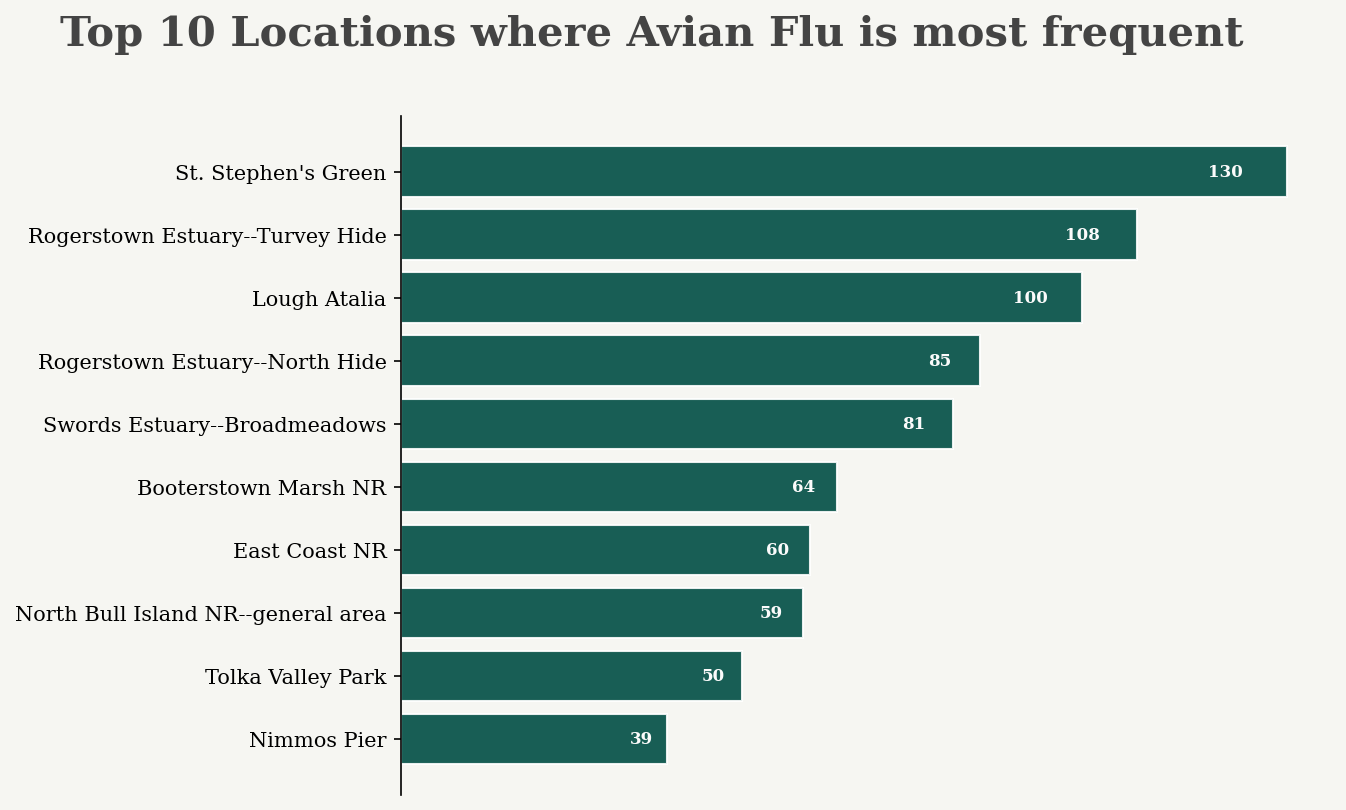

In [30]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=150)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color) 

# Top infected locations 
data = top_infected_locations

color_map = ['#004D44' for _ in range(len(data))]
ax.barh(data.index, data, 
       edgecolor='white',color=color_map, alpha=0.9)

# diff color text
for i in range(0,10):
    ax.annotate(list(data)[i], 
                   xy=(data[i]-(data[i]*0.05), i), 
                   va = 'center', ha='right', fontweight='bold',fontfamily='serif',fontsize=8, color='#FBFBFB')

ax.axes.get_xaxis().set_ticks([])
ax.invert_yaxis()

for s in ['top', 'bottom', 'right']:
    ax.spines[s].set_visible(False)
    
ax.text(-50,-2.0,'Top 10 Locations where Avian Flu is most frequent',
        fontfamily='serif',fontsize=20,fontweight='bold',color='#444444')

plt.show()

## Month Overview

In [62]:
infected_bymonth = infected_birds.groupby('Month').size().sort_index(ascending=True)
def monthFormatter(month):
    """
    Take the representative number of a month and return its abbreviation
    """
    switcher = {
        1: "Jan",
        2: "Feb",
        3: "Mar",
        4: "Apr",
        5: "May",
        6: "Jun",
        7: "Jul",
        8: "Aug",
        9: "Sep",
        10: "Oct",
        11: "Nov",
        12: "Dec"
    }
    
    return switcher.get(month, "Invalid month")

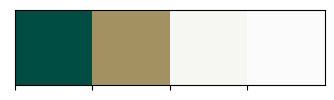

In [70]:
sns.palplot(['#004D44','#A39161','#F6F6F2','#FBFBFB'])

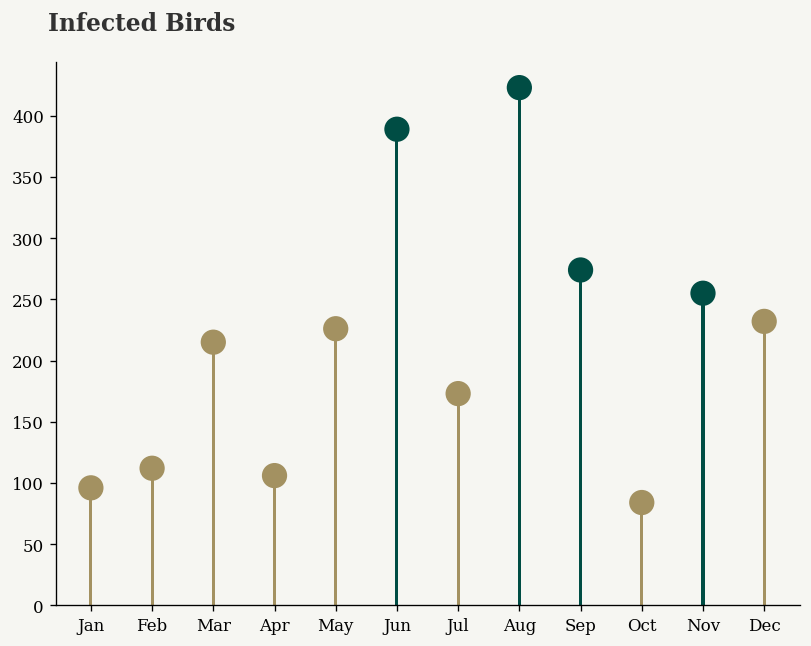

In [109]:
fig, ax = plt.subplots(1,1, figsize=(8, 6),dpi=120)

background_color = "#F6F6F2"
fig.patch.set_facecolor(background_color) # figure background color
ax.set_facecolor(background_color)

ax.text(-0.5, 470, 'Infected Birds', fontsize=14, fontweight='bold', fontfamily='serif', color="#323232")
color_map = ['#004D44' if value > 250 else '#A39161' for index, value in infected_bymonth.items()]

# MONTH OVERVIEW
ax.bar(np.arange(len(infected_bymonth.index))+0.2, infected_bymonth, zorder=1, color=color_map, width=0.05)
ax.scatter(np.arange(len(infected_bymonth.index))+0.2, infected_bymonth, zorder=1,s=200, color=color_map)

ax.set_xticks(np.arange(len(infected_bymonth.index))+0.4 / 2)
ax.set_xticklabels(map(monthFormatter,list(infected_bymonth.index)),rotation=0)

for s in ['top', 'right']:
    ax.spines[s].set_visible(False)

plt.show()

In [16]:
bird_flu.groupby('Date')['target_H5_HPAI'].agg(['count'])

,count
Date,
01/01/2014,2
01/01/2017,1
01/01/2018,1
01/01/2019,5
01/01/2020,10
...,...
31/10/2019,16
31/12/2009,12
31/12/2015,21


## Ordnance Survey Ireland

>https://data-osi.opendata.arcgis.com/

## Administrative Areas - OSi National Statutory Boundaries

https://data-osi.opendata.arcgis.com/datasets/0d5984f732c54246bd087768223c92eb_0?geometry=-7.002%2C53.175%2C-5.684%2C53.319

In [18]:
# GeoJSON API
url_geoJSON = 'https://opendata.arcgis.com/datasets/0d5984f732c54246bd087768223c92eb_0.geojson'
admin_areas = gpd.read_file(url_geoJSON, driver='GeoJSON')

In [19]:
# check if the shapefile is grand
admin_areas.head()

,ENGLISH,GAEILGE,CONTAE,COUNTY,PROVINCE,GUID,CENTROID_X,CENTROID_Y,AREA,CC_ID,OBJECTID,Shape__Area,Shape__Length,geometry
0,DUBLIN CITY COUNCIL,None,Baile Átha Cliath,DUBLIN,Leinster,2ae19629-1433-13a3-e055-000000000001,716469.75,735272.06,1.283502e+08,265011,1,1.283502e+08,101493.212412,"POLYGON ((-6.38258 53.33367, -6.38261 53.33370..."
1,CORK CITY COUNCIL,None,Corcaigh,CORK,Munster,2ae19629-1434-13a3-e055-000000000001,565833.13,571933.83,1.865976e+08,45511,2,1.865976e+08,80293.730785,"POLYGON ((-8.38436 51.90533, -8.38425 51.90529..."
2,GALWAY CITY COUNCIL,None,Gaillimh,GALWAY,Connacht,2ae19629-1435-13a3-e055-000000000001,530067.66,726500.52,5.069505e+07,65011,3,5.069505e+07,64020.725628,"MULTIPOLYGON (((-9.13605 53.26682, -9.13606 53..."
3,OFFALY COUNTY COUNCIL,None,Uíbh Fhailí,OFFALY,Leinster,2ae19629-1496-13a3-e055-000000000001,631261.72,709672.35,2.000025e+09,185001,4,2.000025e+09,389927.708615,"POLYGON ((-7.97902 53.33689, -7.97878 53.33684..."
4,WICKLOW COUNTY COUNCIL,None,Cill Mhantáin,WICKLOW,Leinster,2ae19629-149e-13a3-e055-000000000001,707784.79,690738.10,2.025161e+09,255001,5,2.025161e+09,320629.958733,"MULTIPOLYGON (((-6.14602 52.78372, -6.14607 52..."


<AxesSubplot:>

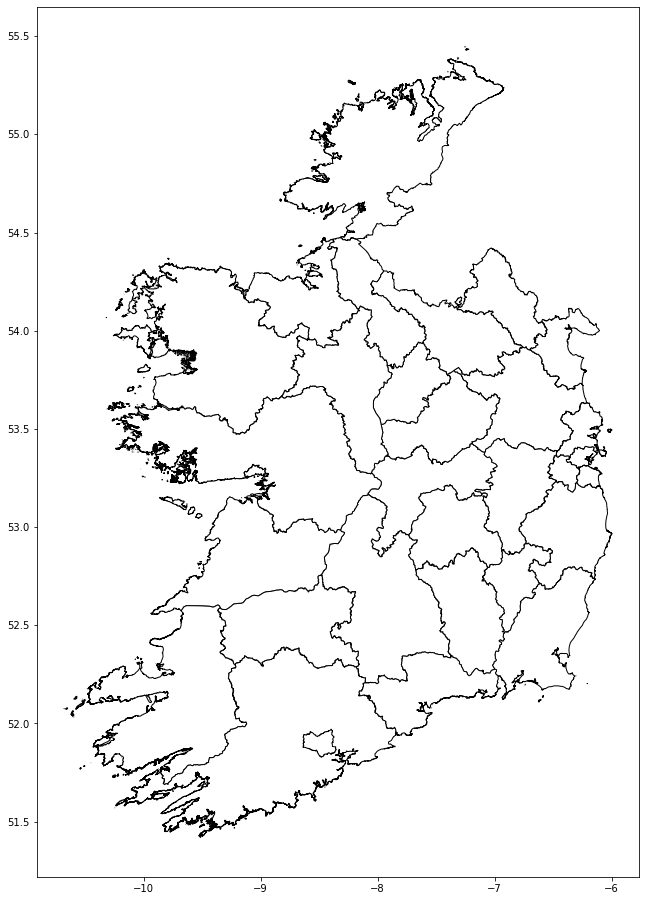

In [20]:
# Plotting the areas from the GeoDataFrame
admin_areas.plot(figsize=(18,16), facecolor='white', edgecolor='black')

In [21]:
# Saving the data downloaded to a local json file
admin_areas.to_file('data/Administrative_Areas_Ireland.json', driver='GeoJSON')